## setup

In [6]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score, precision_score, recall_score, accuracy_score, f1_score
import torch.nn.functional as F
from sklearn.preprocessing import LabelEncoder
import copy
import numpy as np
from sklearn.metrics import roc_auc_score, precision_score, recall_score, accuracy_score, f1_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import LabelEncoder
import random 
import copy
from scipy.signal import butter, sosfiltfilt

le = LabelEncoder()
batch_size=32
X_list = []
y_list = []
subjects_list = []

fold_results = []
fold_conf_mats = []
num_epochs = 60

for i in range(1, 10):
    Xi = np.load(fr"/home/hia2037/EEGMotorImagery-Classification/Data/X{i}.npy").astype(np.float32)
    Xi = Xi[:, None, :, :]

    yi = np.load(fr"/home/hia2037/EEGMotorImagery-Classification/Data/X{i}L.npy")

    X_list.append(Xi)
    y_list.append(yi)

    subjects_list.append(np.full(len(yi), i))

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)
subjects = np.concatenate(subjects_list, axis=0)

le = LabelEncoder()
y_cv = le.fit_transform(y).astype(np.int64)
X_cv = X.astype(np.float32)

logo = LeaveOneGroupOut()
k = len(np.unique(subjects))


def evaluate(model, X, Y, params, batch_size=64):
    was_training = model.training
    model.eval()

    all_probs = []
    all_preds = []

    with torch.no_grad():
        for s in range(0, len(X), batch_size):
            e = min(s + batch_size, len(X))

            inputs = torch.from_numpy(X[s:e]).float()

            inputs = inputs.cuda(0)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(probs.argmax(dim=1).cpu().numpy())

    probs = np.concatenate(all_probs, axis=0)
    pred_labels = np.concatenate(all_preds, axis=0)


    results = []

    for param in params:
        if param == "acc":
            results.append(accuracy_score(Y, pred_labels))

        elif param == "auc":
            try:
                results.append(
                    roc_auc_score(
                        Y,
                        probs,
                        multi_class="ovo",
                        labels=np.arange(probs.shape[1])
                    )
                )
            except ValueError:
                results.append(None)

        elif param == "fmeasure":
            results.append(f1_score(Y, pred_labels, average="macro"))

    

    if was_training:
        model.train()
    else:
        model.eval()
    return results

In [7]:
#input: (batch, 1, Chans, Samples)

class EEGNetTorch(nn.Module):
    def __init__(self, nb_classes=4, Chans=22, Samples=1001, dropoutRate=0.5, kernLength=125, F1=8, D=2, F2=16, dropoutType="Dropout"):
        super().__init__()

        DropoutLayer = nn.Dropout


        ##################################################Block 1#################################################
        #Conv2D: F1 filters, (1, kernLength) kernel size
        self.conv_temporal = nn.Conv2d(in_channels=1, out_channels=F1,
            kernel_size=(1, kernLength),
            padding="same", bias=False,
        )

        #BatchNormalization
        self.bn1 = nn.BatchNorm2d(F1, eps=1e-3, momentum=0.01)

        # DepthwiseConv2D: kernel size (chans, 1)
        self.conv_spatial = nn.Conv2d(in_channels=F1, out_channels=F1 * D,
            kernel_size=(Chans, 1),
            groups=F1, bias=False,
        )

        self.bn2 = nn.BatchNorm2d(F1 * D, eps=1e-3, momentum=0.01)

        #activation

        self.pool1 = nn.AvgPool2d(kernel_size=(1, 4))

        self.drop1 = DropoutLayer(dropoutRate)

        ##################################################Block 2#################################################

        #SeparableConv2D: (1,16) kernel size
        self.sepConv = nn.Conv2d(in_channels=F1 * D, out_channels=F1 * D,
            kernel_size=(1, 16),
            padding="same",
            groups=F1 * D, bias=False,
        )

        #SeparableConv2D: F2 filters, 
        self.sep_pointwise = nn.Conv2d(in_channels=F1 * D, out_channels=F2,
            kernel_size=(1, 1),
            bias=False,
        )

        self.bn3 = nn.BatchNorm2d(F2, eps=1e-3, momentum=0.01)
        self.pool2 = nn.AvgPool2d(kernel_size=(1, 8))
        self.drop2 = DropoutLayer(dropoutRate)

        with torch.no_grad():
            dummy = torch.zeros(1, 1, Chans, Samples)
            out = self._features(dummy)
            self.flatten_dim = out.flatten(start_dim=1).shape[1]

        self.classifier = nn.Linear(self.flatten_dim, nb_classes)

    def _features(self, x):
        x = self.conv_temporal(x)
        x = self.bn1(x)

        x = self.conv_spatial(x)

        x = self.bn2(x)
        x = F.elu(x)
        x = self.pool1(x)
        x = self.drop1(x)

        x = self.sepConv(x)
        x = self.sep_pointwise(x)
        x = self.bn3(x)
        x = F.elu(x)
        x = self.pool2(x)
        x = self.drop2(x)

        return x

    def forward(self, x):
        x = self._features(x)
        x = torch.flatten(x, start_dim=1)
        x = self.classifier(x)
        return x

In [8]:
batch_size = 32
num_epochs = 60
k = 9
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

nb_classes = len(np.unique(y_cv))
Chans = X_cv.shape[2]
Samples = X_cv.shape[3]

params = ["acc", "auc", "fmeasure"]

patience = 15
min_delta = 1e-4
fold_results = []


In [9]:
def _frequency_mask(start_freq, bw, X):
    X = X.copy()

    stop_freq = start_freq + bw

    sos = butter(
        N=4,
        Wn=[start_freq, stop_freq],
        btype="bandstop",
        fs=250,
        output="sos"
    )

    return sosfiltfilt(sos, X, axis=-1)

In [10]:
freqs=[0,0,0]
nums=3
rng = np.random.default_rng(seed=42)

for i in range(nums):
    freqs[i]=rng.uniform(4, 32)
    

## both



================ BANDWIDTH 4 ================

========== FREQ 25.670769359566975, BANDWIDTH 4 ==========


/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/torch/nn/modules/conv.py:560: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1090.)
  return F.conv2d(


Early stopping at epoch 59
[[0.52083333 0.17361111 0.04861111 0.25694444]
 [0.02083333 0.77083333 0.19444444 0.01388889]
 [0.02083333 0.13888889 0.84027778 0.        ]
 [0.36805556 0.13888889 0.00694444 0.48611111]]

Fold 1 Final Validation -
{'acc': 0.6545138888888888, 'auc': np.float64(0.8886598186728395), 'fmeasure': 0.6476661850204156}
Early stopping at epoch 16
[[0.03472222 0.82638889 0.08333333 0.05555556]
 [0.02777778 0.8125     0.125      0.03472222]
 [0.02777778 0.84027778 0.08333333 0.04861111]
 [0.02083333 0.86805556 0.08333333 0.02777778]]

Fold 2 Final Validation -
{'acc': 0.23958333333333334, 'auc': np.float64(0.4954145769032922), 'fmeasure': 0.15128327144101905}
Early stopping at epoch 36
[[0.51388889 0.14583333 0.125      0.21527778]
 [0.04861111 0.86111111 0.01388889 0.07638889]
 [0.09027778 0.11805556 0.67361111 0.11805556]
 [0.13194444 0.02777778 0.01388889 0.82638889]]

Fold 3 Final Validation -
{'acc': 0.71875, 'auc': np.float64(0.9236914866255144), 'fmeasure': 0.7

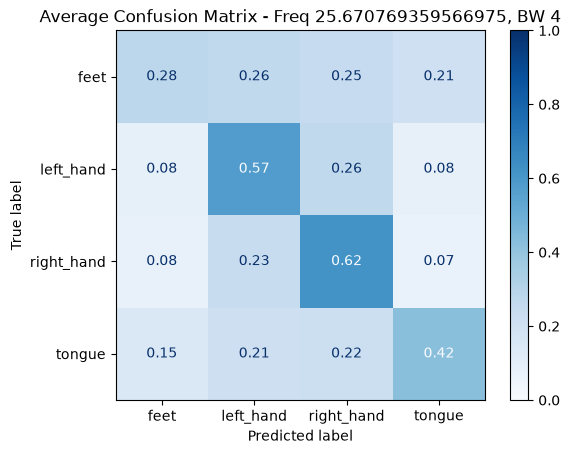


========== FREQ 16.288596313057464, BANDWIDTH 4 ==========
[[0.68055556 0.22222222 0.03472222 0.0625    ]
 [0.01388889 0.90277778 0.08333333 0.        ]
 [0.04861111 0.25       0.70138889 0.        ]
 [0.43055556 0.22916667 0.00694444 0.33333333]]

Fold 1 Final Validation -
{'acc': 0.6545138888888888, 'auc': np.float64(0.8982124485596706), 'fmeasure': 0.6413010483002087}
Early stopping at epoch 16
[[0.02777778 0.27083333 0.40972222 0.29166667]
 [0.03472222 0.34027778 0.38194444 0.24305556]
 [0.03472222 0.36111111 0.36805556 0.23611111]
 [0.08333333 0.36111111 0.34722222 0.20833333]]

Fold 2 Final Validation -
{'acc': 0.2361111111111111, 'auc': np.float64(0.48740917566872427), 'fmeasure': 0.2107201537124545}
Early stopping at epoch 55
[[0.47222222 0.14583333 0.07638889 0.30555556]
 [0.03472222 0.74305556 0.         0.22222222]
 [0.05555556 0.15972222 0.52083333 0.26388889]
 [0.03472222 0.04166667 0.         0.92361111]]

Fold 3 Final Validation -
{'acc': 0.6649305555555556, 'auc': np.f

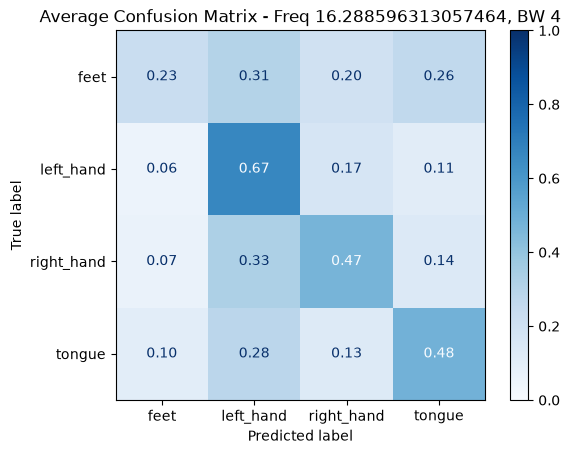


========== FREQ 28.04074175751871, BANDWIDTH 4 ==========
Early stopping at epoch 53
[[0.56944444 0.15277778 0.0625     0.21527778]
 [0.02777778 0.71527778 0.25       0.00694444]
 [0.02777778 0.04861111 0.92361111 0.        ]
 [0.44444444 0.19444444 0.00694444 0.35416667]]

Fold 1 Final Validation -
{'acc': 0.640625, 'auc': np.float64(0.8880650398662552), 'fmeasure': 0.6252089420575827}
Early stopping at epoch 30
[[0.40277778 0.25694444 0.29166667 0.04861111]
 [0.28472222 0.44444444 0.26388889 0.00694444]
 [0.29861111 0.25       0.43055556 0.02083333]
 [0.27083333 0.43055556 0.23611111 0.0625    ]]

Fold 2 Final Validation -
{'acc': 0.3350694444444444, 'auc': np.float64(0.6112075617283951), 'fmeasure': 0.30683925426241254}
Early stopping at epoch 41
[[0.42361111 0.04861111 0.23611111 0.29166667]
 [0.06944444 0.65972222 0.03472222 0.23611111]
 [0.00694444 0.01388889 0.8125     0.16666667]
 [0.04166667 0.00694444 0.00694444 0.94444444]]

Fold 3 Final Validation -
{'acc': 0.7100694444444

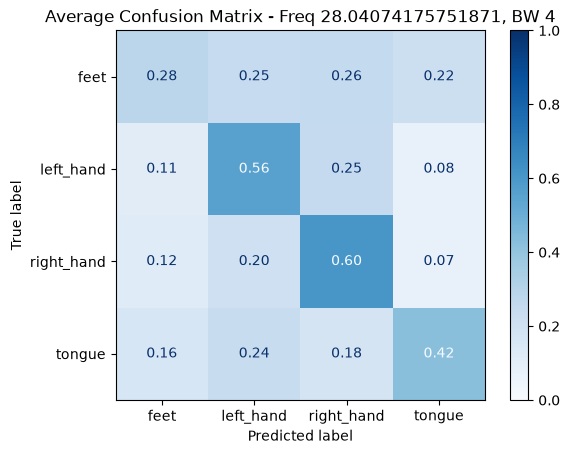


========== BANDWIDTH 4 ==========
acc: 0.4678 ± 0.0055
auc: 0.7324 ± 0.0098
fmeasure: 0.4348 ± 0.0097


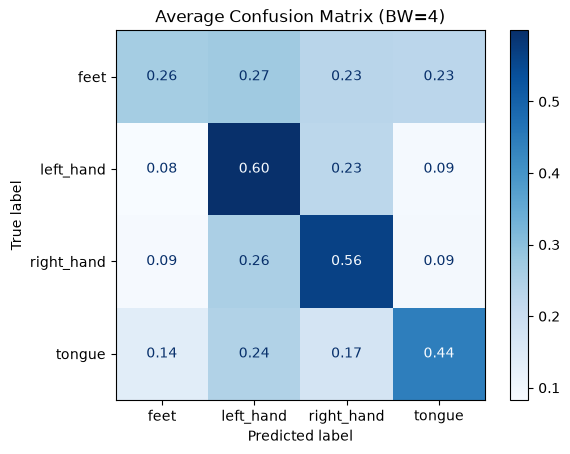



================ BANDWIDTH 6 ================

========== FREQ 25.670769359566975, BANDWIDTH 6 ==========
Early stopping at epoch 51
[[0.63888889 0.22222222 0.05555556 0.08333333]
 [0.02083333 0.8125     0.15972222 0.00694444]
 [0.02777778 0.13888889 0.82638889 0.00694444]
 [0.54861111 0.25       0.00694444 0.19444444]]

Fold 1 Final Validation -
{'acc': 0.6180555555555556, 'auc': np.float64(0.858008616255144), 'fmeasure': 0.5874426518199792}
Early stopping at epoch 16
[[0.15972222 0.66666667 0.13888889 0.03472222]
 [0.19444444 0.71527778 0.08333333 0.00694444]
 [0.17361111 0.68055556 0.13194444 0.01388889]
 [0.17361111 0.65972222 0.15277778 0.01388889]]

Fold 2 Final Validation -
{'acc': 0.2552083333333333, 'auc': np.float64(0.507370434670782), 'fmeasure': 0.19329317339926735}
Early stopping at epoch 49
[[0.625      0.0625     0.03472222 0.27777778]
 [0.0625     0.63888889 0.00694444 0.29166667]
 [0.09027778 0.06944444 0.57638889 0.26388889]
 [0.06944444 0.00694444 0.         0.9236

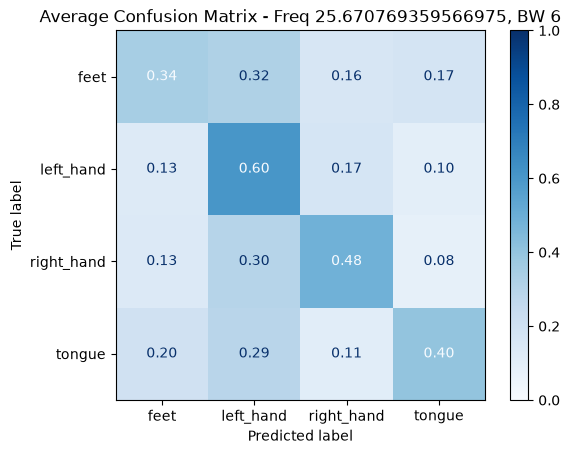


========== FREQ 16.288596313057464, BANDWIDTH 6 ==========
[[0.77777778 0.09722222 0.02777778 0.09722222]
 [0.02777778 0.8125     0.14583333 0.01388889]
 [0.04166667 0.19444444 0.75       0.01388889]
 [0.49305556 0.15277778 0.         0.35416667]]

Fold 1 Final Validation -
{'acc': 0.6736111111111112, 'auc': np.float64(0.8956404320987655), 'fmeasure': 0.660836265059532}
Early stopping at epoch 16
[[0.         0.95138889 0.02777778 0.02083333]
 [0.00694444 0.95138889 0.01388889 0.02777778]
 [0.         0.97222222 0.00694444 0.02083333]
 [0.         0.99305556 0.00694444 0.        ]]

Fold 2 Final Validation -
{'acc': 0.23958333333333334, 'auc': np.float64(0.5046577610596709), 'fmeasure': 0.10100702004655004}
Early stopping at epoch 43
[[0.51388889 0.06944444 0.06944444 0.34722222]
 [0.04166667 0.6875     0.01388889 0.25694444]
 [0.08333333 0.04166667 0.55555556 0.31944444]
 [0.03472222 0.01388889 0.         0.95138889]]

Fold 3 Final Validation -
{'acc': 0.6770833333333334, 'auc': np.f

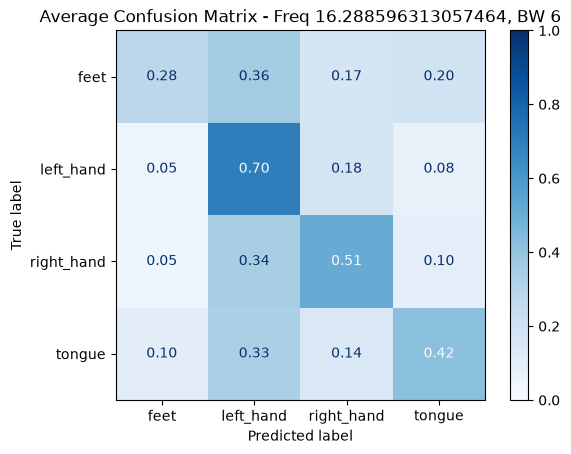


========== FREQ 28.04074175751871, BANDWIDTH 6 ==========
Early stopping at epoch 50
[[0.52083333 0.24305556 0.06944444 0.16666667]
 [0.02083333 0.85416667 0.11805556 0.00694444]
 [0.01388889 0.20138889 0.78472222 0.        ]
 [0.47222222 0.18055556 0.00694444 0.34027778]]

Fold 1 Final Validation -
{'acc': 0.625, 'auc': np.float64(0.8845084233539094), 'fmeasure': 0.611324500233277}
Early stopping at epoch 29
[[0.20833333 0.54166667 0.20833333 0.04166667]
 [0.125      0.65972222 0.21527778 0.        ]
 [0.18055556 0.52083333 0.29861111 0.        ]
 [0.125      0.68055556 0.17361111 0.02083333]]

Fold 2 Final Validation -
{'acc': 0.296875, 'auc': np.float64(0.615061567644033), 'fmeasure': 0.24905659786730858}
Early stopping at epoch 34
[[0.45833333 0.16666667 0.13194444 0.24305556]
 [0.03472222 0.85416667 0.01388889 0.09722222]
 [0.0625     0.09027778 0.75694444 0.09027778]
 [0.05555556 0.02083333 0.02083333 0.90277778]]

Fold 3 Final Validation -
{'acc': 0.7430555555555556, 'auc': np.

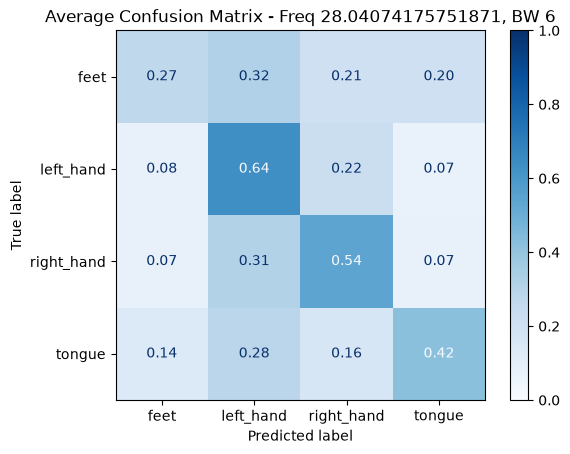


========== BANDWIDTH 6 ==========
acc: 0.4675 ± 0.0072
auc: 0.7284 ± 0.0046
fmeasure: 0.4311 ± 0.0043


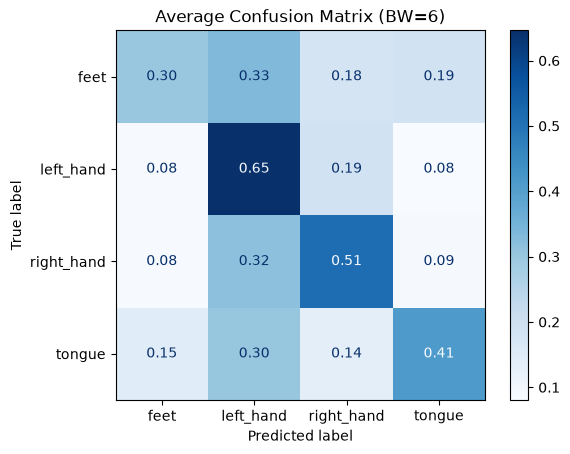



================ BANDWIDTH 8 ================

========== FREQ 25.670769359566975, BANDWIDTH 8 ==========
Early stopping at epoch 43
[[0.47222222 0.28472222 0.04861111 0.19444444]
 [0.02083333 0.83333333 0.13194444 0.01388889]
 [0.01388889 0.14583333 0.84027778 0.        ]
 [0.3125     0.3125     0.02083333 0.35416667]]

Fold 1 Final Validation -
{'acc': 0.625, 'auc': np.float64(0.8669785236625515), 'fmeasure': 0.6106117060103603}
Early stopping at epoch 16
[[0.         0.86805556 0.09027778 0.04166667]
 [0.         0.82638889 0.11805556 0.05555556]
 [0.         0.85416667 0.11805556 0.02777778]
 [0.         0.82638889 0.13888889 0.03472222]]

Fold 2 Final Validation -
{'acc': 0.24479166666666666, 'auc': np.float64(0.49566374099794247), 'fmeasure': 0.14969886451425743}
Early stopping at epoch 59
[[0.43055556 0.08333333 0.13888889 0.34722222]
 [0.02777778 0.75       0.00694444 0.21527778]
 [0.02777778 0.09722222 0.70833333 0.16666667]
 [0.04166667 0.01388889 0.01388889 0.93055556]]

F

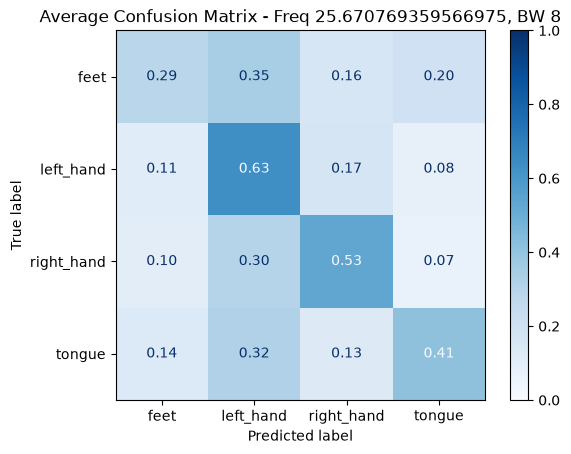


========== FREQ 16.288596313057464, BANDWIDTH 8 ==========
[[0.79861111 0.09722222 0.04166667 0.0625    ]
 [0.04166667 0.875      0.07638889 0.00694444]
 [0.03472222 0.25694444 0.70138889 0.00694444]
 [0.67361111 0.13888889 0.         0.1875    ]]

Fold 1 Final Validation -
{'acc': 0.640625, 'auc': np.float64(0.8793804655349794), 'fmeasure': 0.6083503982355085}
Early stopping at epoch 35
[[0.35416667 0.28472222 0.16666667 0.19444444]
 [0.26388889 0.5        0.20833333 0.02777778]
 [0.375      0.31944444 0.26388889 0.04166667]
 [0.22222222 0.43055556 0.1875     0.15972222]]

Fold 2 Final Validation -
{'acc': 0.3194444444444444, 'auc': np.float64(0.5956629372427984), 'fmeasure': 0.3069083480447508}
Early stopping at epoch 42
[[0.53472222 0.06944444 0.11111111 0.28472222]
 [0.11111111 0.50694444 0.02083333 0.36111111]
 [0.04861111 0.02083333 0.74305556 0.1875    ]
 [0.05555556 0.00694444 0.         0.9375    ]]

Fold 3 Final Validation -
{'acc': 0.6805555555555556, 'auc': np.float64(0.92

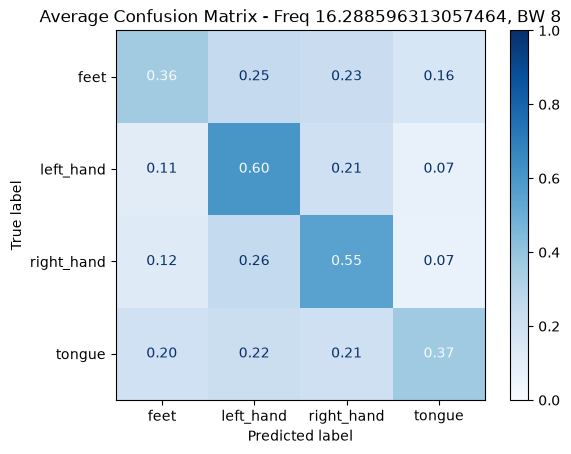


========== FREQ 28.04074175751871, BANDWIDTH 8 ==========
Early stopping at epoch 52
[[0.66666667 0.15972222 0.03472222 0.13888889]
 [0.04166667 0.89583333 0.0625     0.        ]
 [0.05555556 0.19444444 0.74305556 0.00694444]
 [0.45833333 0.21527778 0.         0.32638889]]

Fold 1 Final Validation -
{'acc': 0.6579861111111112, 'auc': np.float64(0.8842472029320989), 'fmeasure': 0.6444259899016742}
Early stopping at epoch 16
[[0.22222222 0.61805556 0.13194444 0.02777778]
 [0.20833333 0.67361111 0.10416667 0.01388889]
 [0.20138889 0.6875     0.11111111 0.        ]
 [0.18055556 0.6875     0.125      0.00694444]]

Fold 2 Final Validation -
{'acc': 0.2534722222222222, 'auc': np.float64(0.5166196469907407), 'fmeasure': 0.1942058499331472}
Early stopping at epoch 52
[[0.52777778 0.04861111 0.09027778 0.33333333]
 [0.09722222 0.67361111 0.00694444 0.22222222]
 [0.08333333 0.04166667 0.69444444 0.18055556]
 [0.05555556 0.00694444 0.         0.9375    ]]

Fold 3 Final Validation -
{'acc': 0.7083

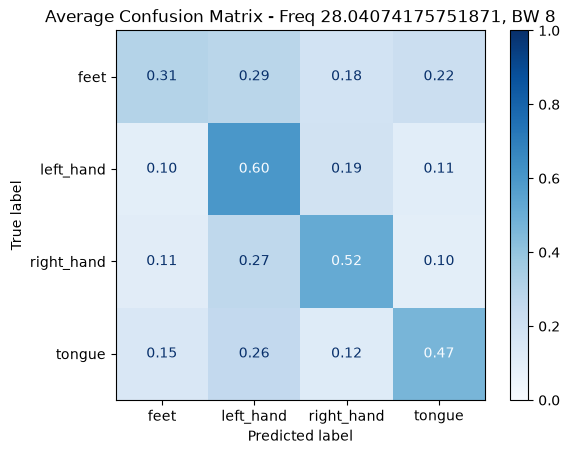


========== BANDWIDTH 8 ==========
acc: 0.4704 ± 0.0027
auc: 0.7336 ± 0.0027
fmeasure: 0.4374 ± 0.0069


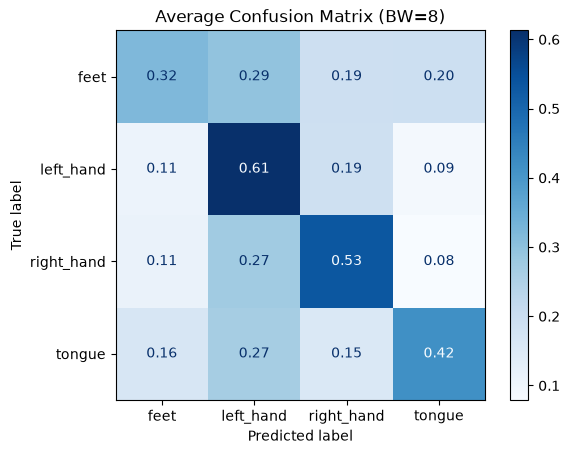

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
num_epochs = 60
results = {}
conf_mats = {}

for bw in [4, 6, 8]:
    bw_results = {}
    bw_conf_mats = {}

    print(f"\n\n================ BANDWIDTH {bw} ================")


    for freq in freqs:
        print(f"\n========== FREQ {freq}, BANDWIDTH {bw} ==========")

        fold_results = []
        fold_conf_mats = []

        for fold, (train_idx, valid_idx) in enumerate(logo.split(X_cv, y_cv, groups=subjects), start=1):

            X_tr = X_cv[train_idx].copy()
            X_va = X_cv[valid_idx].copy()
            
            y_tr = y_cv[train_idx]
            y_va = y_cv[valid_idx]

            X_tr = _frequency_mask(freq, bw, X_tr).copy()
            X_va = _frequency_mask(freq, bw, X_va).copy()

            train_ds = TensorDataset(
                torch.tensor(X_tr, dtype=torch.float32),
                torch.tensor(y_tr, dtype=torch.long)
            )

            valid_ds = TensorDataset(
                torch.tensor(X_va, dtype=torch.float32),
                torch.tensor(y_va, dtype=torch.long)
            )

            train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
            valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

            net = EEGNetTorch(
                nb_classes=4,
                Chans=22,
                Samples=1001,
                kernLength=64,
                F1=32,
                D=4,
                F2=16,
                dropoutRate=0.4854763234903182,
            ).to(device)

            optimizer = torch.optim.Adam(
                net.parameters(),
                lr=0.0004102432506048275
            )

            criterion = torch.nn.CrossEntropyLoss()

            best_val_loss = float("inf")
            best_model_state = None
            epochs_without_improvement = 0

            for epoch in range(num_epochs):
                net.train()
                running_loss = 0.0
                n_seen = 0

                for inputs, labels in train_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    optimizer.zero_grad(set_to_none=True)
                    outputs = net(inputs)
                    loss = criterion(outputs, labels)

                    loss.backward()
                    optimizer.step()

                    running_loss += loss.item() * inputs.size(0)
                    n_seen += inputs.size(0)

                train_loss = running_loss / n_seen

                net.eval()
                val_loss = 0.0
                val_seen = 0

                with torch.no_grad():
                    for inputs, labels in valid_loader:
                        inputs = inputs.to(device)
                        labels = labels.to(device)

                        outputs = net(inputs)
                        loss = criterion(outputs, labels)

                        val_loss += loss.item() * inputs.size(0)
                        val_seen += inputs.size(0)

                val_loss = val_loss / val_seen

                if val_loss < best_val_loss - min_delta:
                    best_val_loss = val_loss
                    best_model_state = copy.deepcopy(net.state_dict())
                    epochs_without_improvement = 0
                else:
                    epochs_without_improvement += 1

                if epochs_without_improvement >= patience:
                    print(f"Early stopping at epoch {epoch + 1}")
                    break

            if best_model_state is not None:
                net.load_state_dict(best_model_state)

            metrics_raw = evaluate(net, X_va, y_va, params)

            if isinstance(metrics_raw, dict):
                metrics = metrics_raw
            else:
                metrics = dict(zip(params, metrics_raw))

            fold_results.append(metrics)

            net.eval()
            with torch.no_grad():
                X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
                outputs = net(X_tensor)
                y_pred = torch.argmax(outputs, dim=1).cpu().numpy()

            cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3], normalize="true")
            print(cm)
            fold_conf_mats.append(cm)

            print(f"\nFold {fold} Final Validation -")
            print(metrics)

        print(f"\n========== FREQ {freq}, BANDWIDTH {bw} Cross-Validation Results ==========")

        avg_metrics = {}

        for metric in params:
            values = [result[metric] for result in fold_results]
            avg_metrics[metric] = {
                "mean": np.mean(values),
                "std": np.std(values)
            }
            print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

        avg_cm = np.mean(fold_conf_mats, axis=0)
        bw_results[freq] = avg_metrics
        bw_conf_mats[freq] = avg_cm

        print("\nAverage Confusion Matrix:")
        print(avg_cm)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=avg_cm,
            display_labels=le.classes_
        )

        disp.plot(
            cmap="Blues",
            im_kw={"vmin": 0, "vmax": 1},
            values_format=".2f"
        )

        plt.title(f"Average Confusion Matrix - Freq {freq}, BW {bw}")
        plt.show()

        bw_results[freq] = avg_metrics
        bw_conf_mats[freq] = avg_cm
    
    bw_avg_metrics = {}

    for metric in params:
        means = [bw_results[f][metric]["mean"] for f in freqs]
        bw_avg_metrics[metric] = {
            "mean": np.mean(means),
            "std": np.std(means)
        }

    bw_avg_cm = np.mean(list(bw_conf_mats.values()), axis=0)

    print(f"\n========== BANDWIDTH {bw} ==========")
    for metric in params:
        print(f"{metric}: {bw_avg_metrics[metric]['mean']:.4f} ± {bw_avg_metrics[metric]['std']:.4f}")

    disp = ConfusionMatrixDisplay(
        confusion_matrix=bw_avg_cm,
        display_labels=le.classes_
    )
    disp.plot(cmap="Blues", values_format=".2f")
    plt.title(f"Average Confusion Matrix (BW={bw})")
    plt.show()

    results[bw] = bw_avg_metrics
    conf_mats[bw] = bw_avg_cm


## train



================ BANDWIDTH 4 ================

========== FREQ 25.670769359566975, BANDWIDTH 4 ==========
Early stopping at epoch 22
[[0.5625     0.15972222 0.04861111 0.22916667]
 [0.02083333 0.69444444 0.26388889 0.02083333]
 [0.01388889 0.0625     0.92361111 0.        ]
 [0.5625     0.19444444 0.00694444 0.23611111]]

Fold 1 Final Validation -
{'acc': 0.6041666666666666, 'auc': np.float64(0.8490909529320988), 'fmeasure': 0.5800203698740035}
Early stopping at epoch 19
[[0.28472222 0.38888889 0.08333333 0.24305556]
 [0.24305556 0.58333333 0.11805556 0.05555556]
 [0.32638889 0.40972222 0.20138889 0.0625    ]
 [0.25       0.45833333 0.14583333 0.14583333]]

Fold 2 Final Validation -
{'acc': 0.3038194444444444, 'auc': np.float64(0.5885798450360081), 'fmeasure': 0.2837557705279921}
[[0.54861111 0.13888889 0.14583333 0.16666667]
 [0.05555556 0.79861111 0.00694444 0.13888889]
 [0.04166667 0.13194444 0.76388889 0.0625    ]
 [0.13888889 0.08333333 0.00694444 0.77083333]]

Fold 3 Final Valid

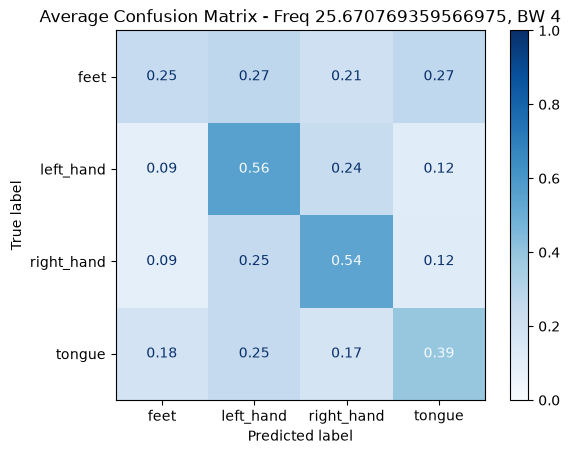


========== FREQ 16.288596313057464, BANDWIDTH 4 ==========
Early stopping at epoch 36
[[0.63888889 0.16666667 0.02777778 0.16666667]
 [0.02777778 0.88194444 0.08333333 0.00694444]
 [0.06944444 0.46527778 0.46527778 0.        ]
 [0.41666667 0.14583333 0.         0.4375    ]]

Fold 1 Final Validation -
{'acc': 0.6059027777777778, 'auc': np.float64(0.8857261123971193), 'fmeasure': 0.5975363960016918}
Early stopping at epoch 16
[[0.01388889 0.09027778 0.88194444 0.01388889]
 [0.         0.17361111 0.82638889 0.        ]
 [0.00694444 0.07638889 0.90972222 0.00694444]
 [0.00694444 0.11111111 0.81944444 0.0625    ]]

Fold 2 Final Validation -
{'acc': 0.2899305555555556, 'auc': np.float64(0.575830279063786), 'fmeasure': 0.1979154354061693}
Early stopping at epoch 53
[[0.5625     0.14583333 0.20138889 0.09027778]
 [0.14583333 0.75694444 0.00694444 0.09027778]
 [0.11111111 0.11805556 0.74305556 0.02777778]
 [0.29861111 0.06944444 0.09722222 0.53472222]]

Fold 3 Final Validation -
{'acc': 0.6493

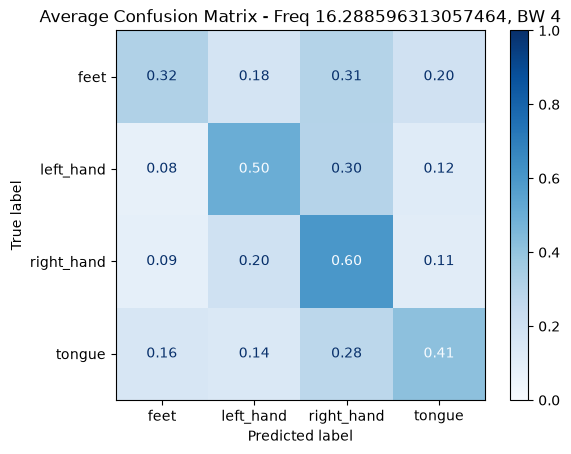


========== FREQ 28.04074175751871, BANDWIDTH 4 ==========
[[0.25       0.1875     0.09027778 0.47222222]
 [0.01388889 0.66666667 0.24305556 0.07638889]
 [0.         0.13888889 0.86111111 0.        ]
 [0.10416667 0.17361111 0.02083333 0.70138889]]

Fold 1 Final Validation -
{'acc': 0.6197916666666666, 'auc': np.float64(0.870675797325103), 'fmeasure': 0.5954382765238124}
Early stopping at epoch 16
[[0.10416667 0.00694444 0.86111111 0.02777778]
 [0.13194444 0.04861111 0.80555556 0.01388889]
 [0.03472222 0.01388889 0.94444444 0.00694444]
 [0.09722222 0.02083333 0.875      0.00694444]]

Fold 2 Final Validation -
{'acc': 0.2760416666666667, 'auc': np.float64(0.5304783950617286), 'fmeasure': 0.16891669119936834}
[[0.41666667 0.23611111 0.07638889 0.27083333]
 [0.04166667 0.79861111 0.00694444 0.15277778]
 [0.03472222 0.22916667 0.56944444 0.16666667]
 [0.10416667 0.07638889 0.         0.81944444]]

Fold 3 Final Validation -
{'acc': 0.6510416666666666, 'auc': np.float64(0.9118200231481483), '

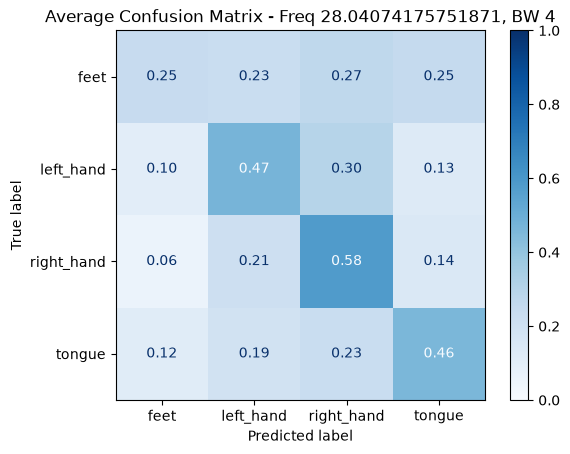


========== BANDWIDTH 4 ==========
acc: 0.4444 ± 0.0103
auc: 0.7151 ± 0.0059
fmeasure: 0.4091 ± 0.0150


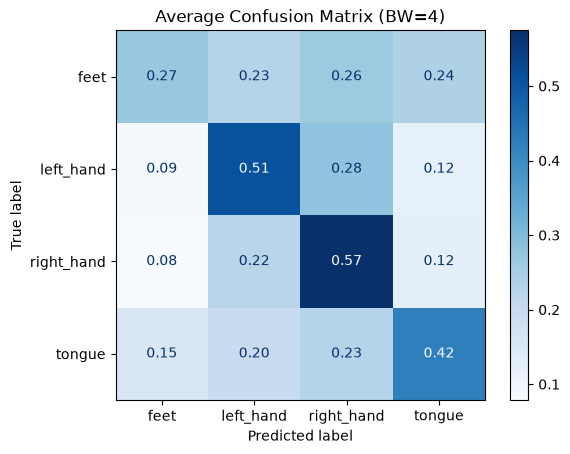



================ BANDWIDTH 6 ================

========== FREQ 25.670769359566975, BANDWIDTH 6 ==========
Early stopping at epoch 36
[[0.51388889 0.125      0.11805556 0.24305556]
 [0.04166667 0.73611111 0.21527778 0.00694444]
 [0.         0.125      0.875      0.        ]
 [0.375      0.09722222 0.02083333 0.50694444]]

Fold 1 Final Validation -
{'acc': 0.6579861111111112, 'auc': np.float64(0.892067740483539), 'fmeasure': 0.6502906487930709}
Early stopping at epoch 16
[[0.         0.91666667 0.08333333 0.        ]
 [0.         0.94444444 0.05555556 0.        ]
 [0.         0.86111111 0.13194444 0.00694444]
 [0.         0.92361111 0.07638889 0.        ]]

Fold 2 Final Validation -
{'acc': 0.2690972222222222, 'auc': np.float64(0.5667679398148149), 'fmeasure': 0.15061331730695143}
Early stopping at epoch 23
[[0.59722222 0.13888889 0.13194444 0.13194444]
 [0.125      0.66666667 0.01388889 0.19444444]
 [0.11111111 0.07638889 0.77083333 0.04166667]
 [0.31944444 0.03472222 0.01388889 0.631

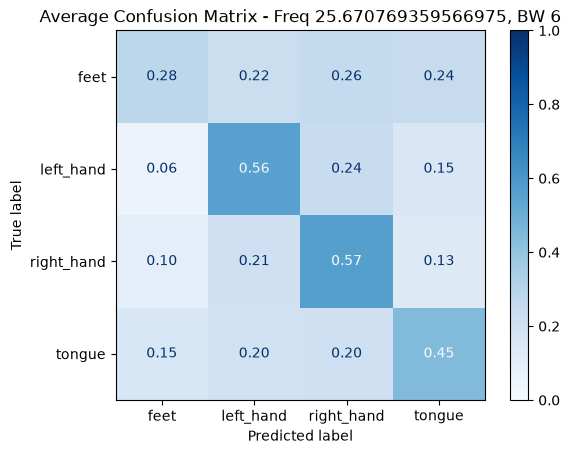


========== FREQ 16.288596313057464, BANDWIDTH 6 ==========
Early stopping at epoch 57
[[0.6875     0.07638889 0.04861111 0.1875    ]
 [0.10416667 0.61805556 0.25694444 0.02083333]
 [0.01388889 0.125      0.86111111 0.        ]
 [0.55555556 0.07638889 0.00694444 0.36111111]]

Fold 1 Final Validation -
{'acc': 0.6319444444444444, 'auc': np.float64(0.8681620531121399), 'fmeasure': 0.621719213178043}
Early stopping at epoch 16
[[0.         0.76388889 0.17361111 0.0625    ]
 [0.02777778 0.73611111 0.21527778 0.02083333]
 [0.00694444 0.72222222 0.24305556 0.02777778]
 [0.         0.68055556 0.25       0.06944444]]

Fold 2 Final Validation -
{'acc': 0.2621527777777778, 'auc': np.float64(0.5634323559670782), 'fmeasure': 0.18829346028440397}
Early stopping at epoch 35
[[0.65277778 0.0625     0.10416667 0.18055556]
 [0.11805556 0.61805556 0.04166667 0.22222222]
 [0.20833333 0.04861111 0.61111111 0.13194444]
 [0.25694444 0.01388889 0.00694444 0.72222222]]

Fold 3 Final Validation -
{'acc': 0.651

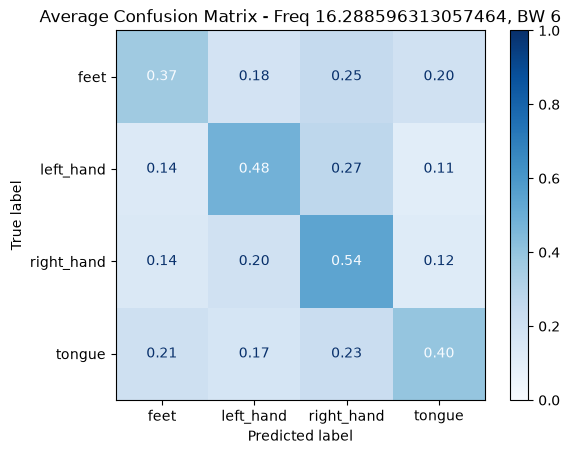


========== FREQ 28.04074175751871, BANDWIDTH 6 ==========
Early stopping at epoch 22
[[0.50694444 0.20833333 0.05555556 0.22916667]
 [0.02083333 0.74305556 0.20833333 0.02777778]
 [0.00694444 0.08333333 0.90972222 0.        ]
 [0.38888889 0.17361111 0.00694444 0.43055556]]

Fold 1 Final Validation -
{'acc': 0.6475694444444444, 'auc': np.float64(0.8709731867283951), 'fmeasure': 0.6361786893548389}
Early stopping at epoch 16
[[0.00694444 0.66666667 0.3125     0.01388889]
 [0.         0.79861111 0.20138889 0.        ]
 [0.01388889 0.66666667 0.31944444 0.        ]
 [0.01388889 0.70833333 0.27083333 0.00694444]]

Fold 2 Final Validation -
{'acc': 0.2829861111111111, 'auc': np.float64(0.566992991255144), 'fmeasure': 0.18664295618211202}
Early stopping at epoch 47
[[0.59027778 0.06944444 0.08333333 0.25694444]
 [0.11805556 0.63888889 0.02083333 0.22222222]
 [0.16666667 0.11111111 0.60416667 0.11805556]
 [0.17361111 0.02083333 0.02083333 0.78472222]]

Fold 3 Final Validation -
{'acc': 0.6545

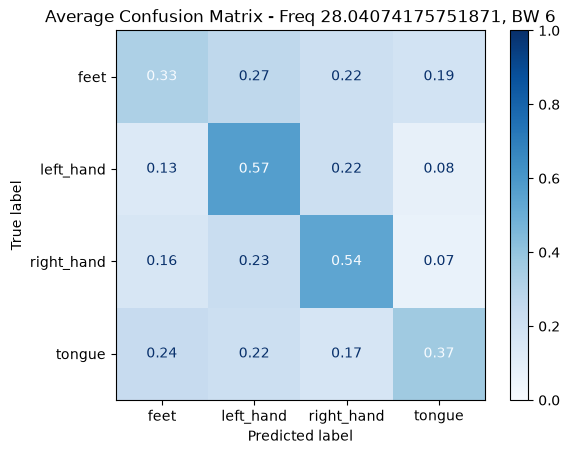


========== BANDWIDTH 6 ==========
acc: 0.4529 ± 0.0065
auc: 0.7129 ± 0.0010
fmeasure: 0.4219 ± 0.0051


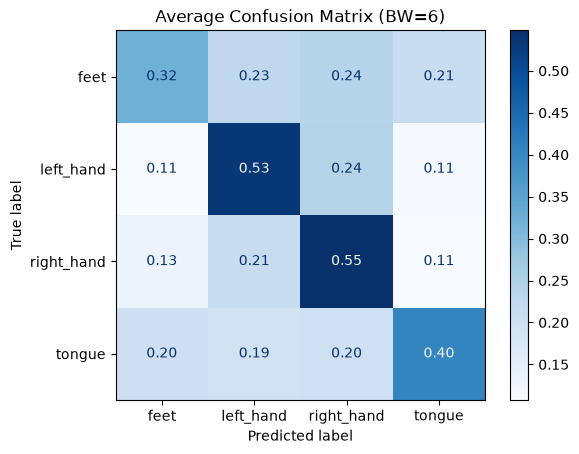



================ BANDWIDTH 8 ================

========== FREQ 25.670769359566975, BANDWIDTH 8 ==========
[[0.74305556 0.11805556 0.0625     0.07638889]
 [0.08333333 0.73611111 0.17361111 0.00694444]
 [0.01388889 0.15972222 0.81944444 0.00694444]
 [0.61805556 0.10416667 0.         0.27777778]]

Fold 1 Final Validation -
{'acc': 0.6440972222222222, 'auc': np.float64(0.8759966563786007), 'fmeasure': 0.6257476022700218}
Early stopping at epoch 16
[[0.18055556 0.18055556 0.10416667 0.53472222]
 [0.13888889 0.28472222 0.14583333 0.43055556]
 [0.13888889 0.28472222 0.17361111 0.40277778]
 [0.22916667 0.18055556 0.15277778 0.4375    ]]

Fold 2 Final Validation -
{'acc': 0.2690972222222222, 'auc': np.float64(0.5681704925411523), 'fmeasure': 0.26027532590593305}
Early stopping at epoch 36
[[0.54861111 0.15972222 0.17361111 0.11805556]
 [0.09722222 0.6875     0.04861111 0.16666667]
 [0.06944444 0.06944444 0.79861111 0.0625    ]
 [0.4375     0.06944444 0.01388889 0.47916667]]

Fold 3 Final Vali

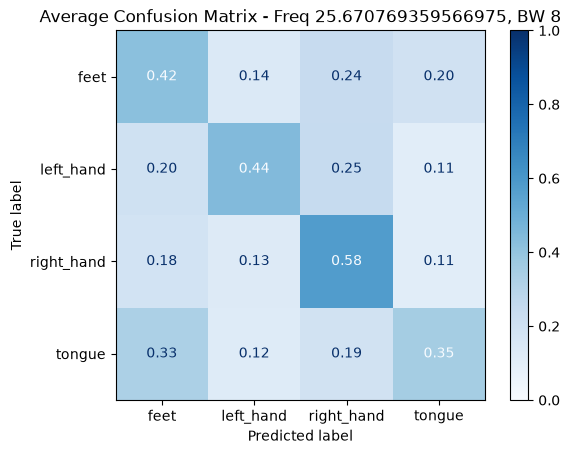


========== FREQ 16.288596313057464, BANDWIDTH 8 ==========
Early stopping at epoch 28
[[0.41666667 0.15972222 0.01388889 0.40972222]
 [0.04166667 0.71527778 0.22222222 0.02083333]
 [0.01388889 0.11805556 0.86805556 0.        ]
 [0.26388889 0.11805556 0.         0.61805556]]

Fold 1 Final Validation -
{'acc': 0.6545138888888888, 'auc': np.float64(0.8910911779835392), 'fmeasure': 0.6465259794266671}
Early stopping at epoch 26
[[0.16666667 0.35416667 0.15277778 0.32638889]
 [0.17361111 0.51388889 0.16666667 0.14583333]
 [0.22222222 0.36111111 0.26388889 0.15277778]
 [0.15972222 0.33333333 0.19444444 0.3125    ]]

Fold 2 Final Validation -
{'acc': 0.3142361111111111, 'auc': np.float64(0.5778838734567902), 'fmeasure': 0.3035220107745432}
Early stopping at epoch 34
[[0.38194444 0.08333333 0.19444444 0.34027778]
 [0.11111111 0.5625     0.03472222 0.29166667]
 [0.07638889 0.0625     0.78472222 0.07638889]
 [0.13194444 0.03472222 0.02083333 0.8125    ]]

Fold 3 Final Validation -
{'acc': 0.635

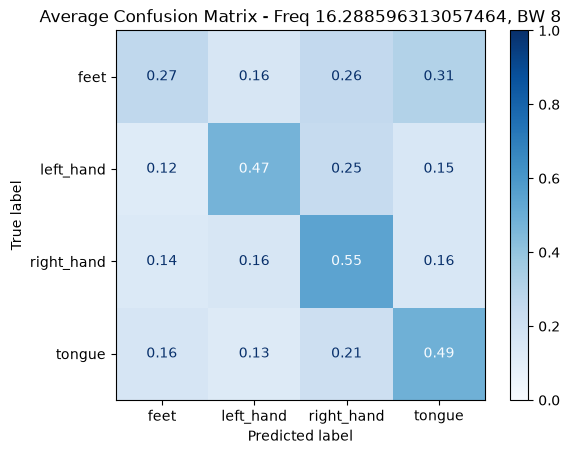


========== FREQ 28.04074175751871, BANDWIDTH 8 ==========
Early stopping at epoch 59
[[0.35416667 0.15277778 0.11805556 0.375     ]
 [0.02083333 0.74305556 0.20833333 0.02777778]
 [0.00694444 0.09722222 0.88888889 0.00694444]
 [0.34027778 0.13888889 0.05555556 0.46527778]]

Fold 1 Final Validation -
{'acc': 0.6128472222222222, 'auc': np.float64(0.8628110532407406), 'fmeasure': 0.5968824101306849}
Early stopping at epoch 16
[[0.0625     0.07638889 0.77777778 0.08333333]
 [0.09027778 0.17361111 0.72222222 0.01388889]
 [0.02083333 0.0625     0.89583333 0.02083333]
 [0.04166667 0.125      0.76388889 0.06944444]]

Fold 2 Final Validation -
{'acc': 0.3003472222222222, 'auc': np.float64(0.5580632716049383), 'fmeasure': 0.22301999100240255}
Early stopping at epoch 30
[[0.40277778 0.09027778 0.25       0.25694444]
 [0.06944444 0.60416667 0.05555556 0.27083333]
 [0.05555556 0.01388889 0.88888889 0.04166667]
 [0.26388889 0.04861111 0.02083333 0.66666667]]

Fold 3 Final Validation -
{'acc': 0.640

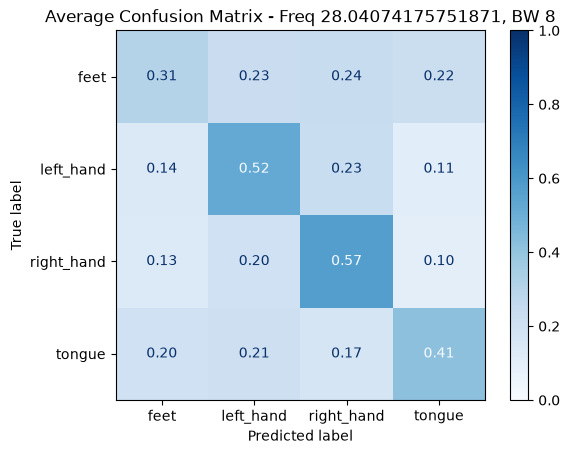


========== BANDWIDTH 8 ==========
acc: 0.4486 ± 0.0038
auc: 0.7115 ± 0.0061
fmeasure: 0.4202 ± 0.0033


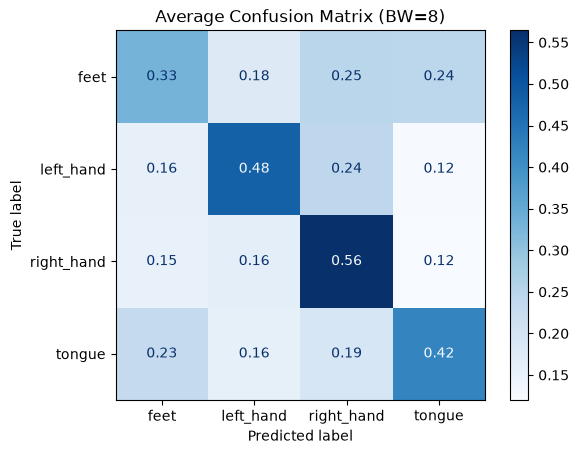

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
num_epochs = 60
results = {}
conf_mats = {}

for bw in [4, 6, 8]:
    bw_results = {}
    bw_conf_mats = {}

    print(f"\n\n================ BANDWIDTH {bw} ================")


    for freq in freqs:
        print(f"\n========== FREQ {freq}, BANDWIDTH {bw} ==========")

        fold_results = []
        fold_conf_mats = []

        for fold, (train_idx, valid_idx) in enumerate(logo.split(X_cv, y_cv, groups=subjects), start=1):

            X_tr = X_cv[train_idx].copy()
            X_va = X_cv[valid_idx].copy()
            
            y_tr = y_cv[train_idx]
            y_va = y_cv[valid_idx]

            X_tr = _frequency_mask(freq, bw, X_tr).copy()

            train_ds = TensorDataset(
                torch.tensor(X_tr, dtype=torch.float32),
                torch.tensor(y_tr, dtype=torch.long)
            )

            valid_ds = TensorDataset(
                torch.tensor(X_va, dtype=torch.float32),
                torch.tensor(y_va, dtype=torch.long)
            )

            train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
            valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

            net = EEGNetTorch(
                nb_classes=4,
                Chans=22,
                Samples=1001,
                kernLength=250,
                F1=8,
                D=1,
                F2=16,
                dropoutRate=0.25550867989537085,
            ).to(device)

            optimizer = torch.optim.Adam(
                net.parameters(),
                lr=0.0026353430928847833, 
                weight_decay=1.4077242503865625e-06
            )

            criterion = torch.nn.CrossEntropyLoss()

            best_val_loss = float("inf")
            best_model_state = None
            epochs_without_improvement = 0

            for epoch in range(num_epochs):
                net.train()
                running_loss = 0.0
                n_seen = 0

                for inputs, labels in train_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    optimizer.zero_grad(set_to_none=True)
                    outputs = net(inputs)
                    loss = criterion(outputs, labels)

                    loss.backward()
                    optimizer.step()

                    running_loss += loss.item() * inputs.size(0)
                    n_seen += inputs.size(0)

                train_loss = running_loss / n_seen

                net.eval()
                val_loss = 0.0
                val_seen = 0

                with torch.no_grad():
                    for inputs, labels in valid_loader:
                        inputs = inputs.to(device)
                        labels = labels.to(device)

                        outputs = net(inputs)
                        loss = criterion(outputs, labels)

                        val_loss += loss.item() * inputs.size(0)
                        val_seen += inputs.size(0)

                val_loss = val_loss / val_seen

                if val_loss < best_val_loss - min_delta:
                    best_val_loss = val_loss
                    best_model_state = copy.deepcopy(net.state_dict())
                    epochs_without_improvement = 0
                else:
                    epochs_without_improvement += 1

                if epochs_without_improvement >= patience:
                    print(f"Early stopping at epoch {epoch + 1}")
                    break

            if best_model_state is not None:
                net.load_state_dict(best_model_state)

            metrics_raw = evaluate(net, X_va, y_va, params)

            if isinstance(metrics_raw, dict):
                metrics = metrics_raw
            else:
                metrics = dict(zip(params, metrics_raw))

            fold_results.append(metrics)

            net.eval()
            with torch.no_grad():
                X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
                outputs = net(X_tensor)
                y_pred = torch.argmax(outputs, dim=1).cpu().numpy()

            cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3], normalize="true")
            print(cm)
            fold_conf_mats.append(cm)

            print(f"\nFold {fold} Final Validation -")
            print(metrics)

        print(f"\n========== FREQ {freq}, BANDWIDTH {bw} Cross-Validation Results ==========")

        avg_metrics = {}

        for metric in params:
            values = [result[metric] for result in fold_results]
            avg_metrics[metric] = {
                "mean": np.mean(values),
                "std": np.std(values)
            }
            print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

        avg_cm = np.mean(fold_conf_mats, axis=0)
        bw_results[freq] = avg_metrics
        bw_conf_mats[freq] = avg_cm

        print("\nAverage Confusion Matrix:")
        print(avg_cm)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=avg_cm,
            display_labels=le.classes_
        )

        disp.plot(
            cmap="Blues",
            im_kw={"vmin": 0, "vmax": 1},
            values_format=".2f"
        )

        plt.title(f"Average Confusion Matrix - Freq {freq}, BW {bw}")
        plt.show()

        bw_results[freq] = avg_metrics
        bw_conf_mats[freq] = avg_cm
    
    bw_avg_metrics = {}

    for metric in params:
        means = [bw_results[f][metric]["mean"] for f in freqs]
        bw_avg_metrics[metric] = {
            "mean": np.mean(means),
            "std": np.std(means)
        }

    bw_avg_cm = np.mean(list(bw_conf_mats.values()), axis=0)

    print(f"\n========== BANDWIDTH {bw} ==========")
    for metric in params:
        print(f"{metric}: {bw_avg_metrics[metric]['mean']:.4f} ± {bw_avg_metrics[metric]['std']:.4f}")

    disp = ConfusionMatrixDisplay(
        confusion_matrix=bw_avg_cm,
        display_labels=le.classes_
    )
    disp.plot(cmap="Blues", values_format=".2f")
    plt.title(f"Average Confusion Matrix (BW={bw})")
    plt.show()

    results[bw] = bw_avg_metrics
    conf_mats[bw] = bw_avg_cm


## test



================ BANDWIDTH 4 ================

========== FREQ 25.670769359566975, BANDWIDTH 4 ==========
[[0.5        0.21527778 0.05555556 0.22916667]
 [0.01388889 0.84027778 0.13194444 0.01388889]
 [0.01388889 0.13888889 0.84027778 0.00694444]
 [0.47916667 0.15972222 0.         0.36111111]]

Fold 1 Final Validation -
{'acc': 0.6354166666666666, 'auc': np.float64(0.882201646090535), 'fmeasure': 0.6222942970837673}
Early stopping at epoch 20
[[0.01388889 0.67361111 0.1875     0.125     ]
 [0.00694444 0.78472222 0.19444444 0.01388889]
 [0.01388889 0.625      0.3125     0.04861111]
 [0.01388889 0.73611111 0.18055556 0.06944444]]

Fold 2 Final Validation -
{'acc': 0.2951388888888889, 'auc': np.float64(0.5935450424382716), 'fmeasure': 0.22030743200916264}
Early stopping at epoch 27
[[0.17361111 0.15972222 0.10416667 0.5625    ]
 [0.00694444 0.74305556 0.02083333 0.22916667]
 [0.00694444 0.09027778 0.73611111 0.16666667]
 [0.00694444 0.01388889 0.         0.97916667]]

Fold 3 Final Valid

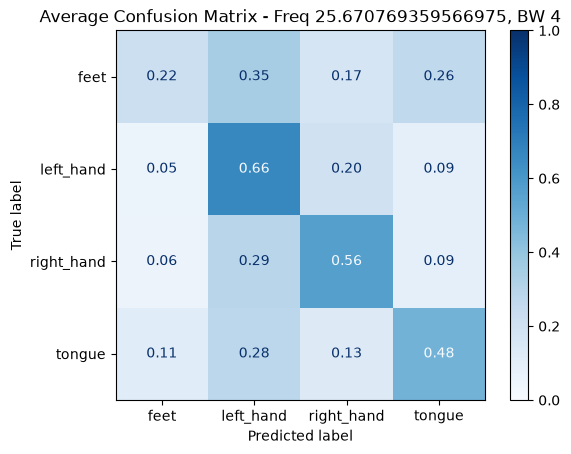


========== FREQ 16.288596313057464, BANDWIDTH 4 ==========
Early stopping at epoch 33
[[0.27083333 0.27083333 0.09027778 0.36805556]
 [0.         0.79861111 0.20138889 0.        ]
 [0.01388889 0.10416667 0.88194444 0.        ]
 [0.23611111 0.25694444 0.01388889 0.49305556]]

Fold 1 Final Validation -
{'acc': 0.6111111111111112, 'auc': np.float64(0.864623521090535), 'fmeasure': 0.587376798330591}
Early stopping at epoch 16
[[0.04861111 0.42361111 0.52083333 0.00694444]
 [0.0625     0.45833333 0.47222222 0.00694444]
 [0.02777778 0.52777778 0.44444444 0.        ]
 [0.0625     0.45138889 0.48611111 0.        ]]

Fold 2 Final Validation -
{'acc': 0.2378472222222222, 'auc': np.float64(0.4789034368569958), 'fmeasure': 0.17633780243912162}
Early stopping at epoch 59
[[0.48611111 0.13888889 0.1875     0.1875    ]
 [0.02777778 0.78472222 0.         0.1875    ]
 [0.03472222 0.06944444 0.71527778 0.18055556]
 [0.08333333 0.02777778 0.02777778 0.86111111]]

Fold 3 Final Validation -
{'acc': 0.7118

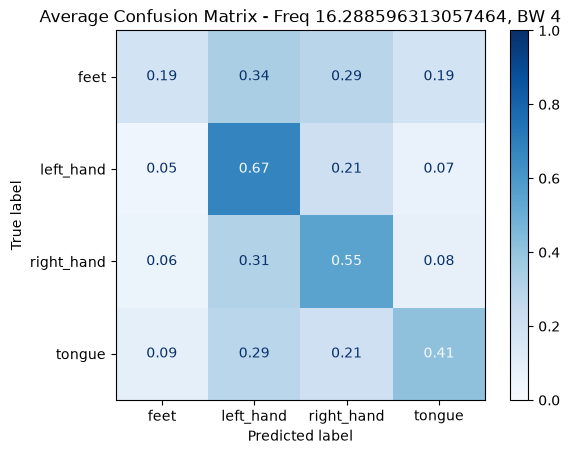


========== FREQ 28.04074175751871, BANDWIDTH 4 ==========
[[0.5625     0.22222222 0.03472222 0.18055556]
 [0.00694444 0.85416667 0.125      0.01388889]
 [0.02083333 0.18055556 0.79166667 0.00694444]
 [0.34722222 0.23611111 0.00694444 0.40972222]]

Fold 1 Final Validation -
{'acc': 0.6545138888888888, 'auc': np.float64(0.8903758359053499), 'fmeasure': 0.645753314511399}
Early stopping at epoch 31
[[0.36805556 0.34722222 0.19444444 0.09027778]
 [0.25694444 0.54861111 0.19444444 0.        ]
 [0.29166667 0.33333333 0.36805556 0.00694444]
 [0.27777778 0.45138889 0.20138889 0.06944444]]

Fold 2 Final Validation -
{'acc': 0.3385416666666667, 'auc': np.float64(0.6191245498971193), 'fmeasure': 0.309925901678866}
[[0.50694444 0.04861111 0.11805556 0.32638889]
 [0.04861111 0.59722222 0.00694444 0.34722222]
 [0.02083333 0.02777778 0.72222222 0.22916667]
 [0.05555556 0.00694444 0.         0.9375    ]]

Fold 3 Final Validation -
{'acc': 0.6909722222222222, 'auc': np.float64(0.9379340277777778), 'fm

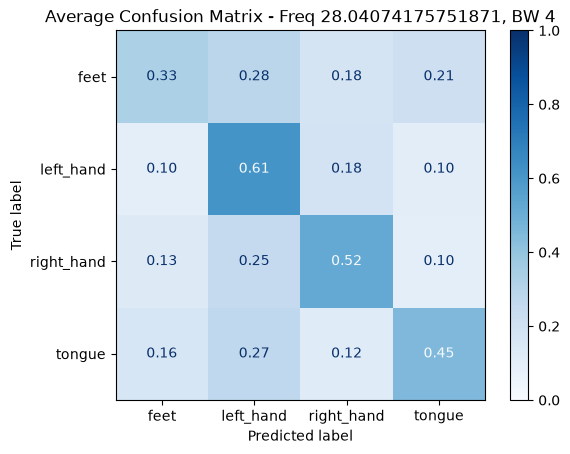


========== BANDWIDTH 4 ==========
acc: 0.4715 ± 0.0115
auc: 0.7367 ± 0.0147
fmeasure: 0.4329 ± 0.0159


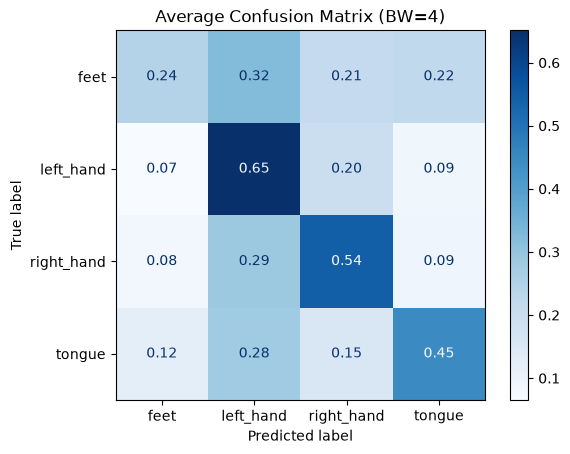



================ BANDWIDTH 6 ================

========== FREQ 25.670769359566975, BANDWIDTH 6 ==========
Early stopping at epoch 36
[[0.5625     0.20138889 0.05555556 0.18055556]
 [0.04166667 0.85416667 0.09722222 0.00694444]
 [0.03472222 0.3125     0.65277778 0.        ]
 [0.38194444 0.19444444 0.         0.42361111]]

Fold 1 Final Validation -
{'acc': 0.6232638888888888, 'auc': np.float64(0.8742283950617283), 'fmeasure': 0.6180766724092356}
Early stopping at epoch 16
[[0.         0.89583333 0.07638889 0.02777778]
 [0.00694444 0.86805556 0.0625     0.0625    ]
 [0.         0.88888889 0.07638889 0.03472222]
 [0.01388889 0.90277778 0.06944444 0.01388889]]

Fold 2 Final Validation -
{'acc': 0.23958333333333334, 'auc': np.float64(0.4965358153292181), 'fmeasure': 0.13110168094924193}
Early stopping at epoch 42
[[0.375      0.11805556 0.07638889 0.43055556]
 [0.04166667 0.68055556 0.         0.27777778]
 [0.05555556 0.04861111 0.61111111 0.28472222]
 [0.05555556 0.02083333 0.         0.9

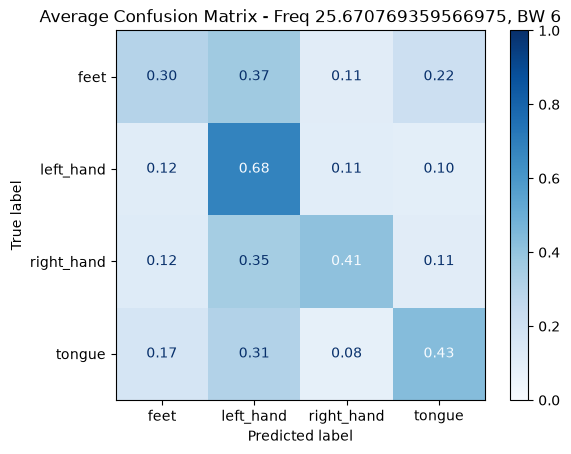


========== FREQ 16.288596313057464, BANDWIDTH 6 ==========
Early stopping at epoch 41
[[0.40972222 0.29861111 0.10416667 0.1875    ]
 [0.         0.8125     0.18055556 0.00694444]
 [0.00694444 0.08333333 0.90972222 0.        ]
 [0.45138889 0.23611111 0.01388889 0.29861111]]

Fold 1 Final Validation -
{'acc': 0.6076388888888888, 'auc': np.float64(0.8670669367283951), 'fmeasure': 0.5827831274194465}
Early stopping at epoch 16
[[0.         0.8125     0.1875     0.        ]
 [0.         0.77777778 0.20833333 0.01388889]
 [0.         0.77083333 0.22916667 0.        ]
 [0.         0.8125     0.1875     0.        ]]

Fold 2 Final Validation -
{'acc': 0.2517361111111111, 'auc': np.float64(0.4914601015946502), 'fmeasure': 0.15639642741025495}
Early stopping at epoch 49
[[0.32638889 0.20138889 0.19444444 0.27777778]
 [0.00694444 0.84027778 0.         0.15277778]
 [0.02083333 0.125      0.66666667 0.1875    ]
 [0.02777778 0.02777778 0.00694444 0.9375    ]]

Fold 3 Final Validation -
{'acc': 0.69

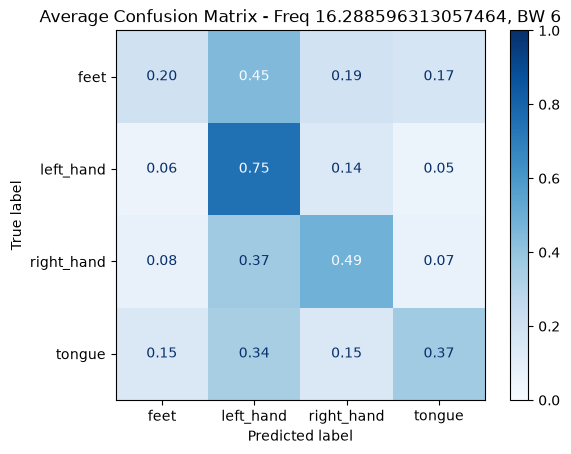


========== FREQ 28.04074175751871, BANDWIDTH 6 ==========
Early stopping at epoch 40
[[0.57638889 0.16666667 0.05555556 0.20138889]
 [0.03472222 0.84722222 0.11111111 0.00694444]
 [0.03472222 0.21527778 0.74305556 0.00694444]
 [0.54861111 0.20138889 0.00694444 0.24305556]]

Fold 1 Final Validation -
{'acc': 0.6024305555555556, 'auc': np.float64(0.8646436149691358), 'fmeasure': 0.5827887412532432}
Early stopping at epoch 25
[[0.16666667 0.48611111 0.19444444 0.15277778]
 [0.10416667 0.70833333 0.17361111 0.01388889]
 [0.16666667 0.5625     0.25       0.02083333]
 [0.06944444 0.70138889 0.13888889 0.09027778]]

Fold 2 Final Validation -
{'acc': 0.3038194444444444, 'auc': np.float64(0.6023341049382717), 'fmeasure': 0.26418150974053406}
Early stopping at epoch 39
[[0.5        0.15277778 0.08333333 0.26388889]
 [0.02777778 0.81944444 0.01388889 0.13888889]
 [0.04166667 0.08333333 0.71527778 0.15972222]
 [0.09027778 0.02777778 0.         0.88194444]]

Fold 3 Final Validation -
{'acc': 0.729

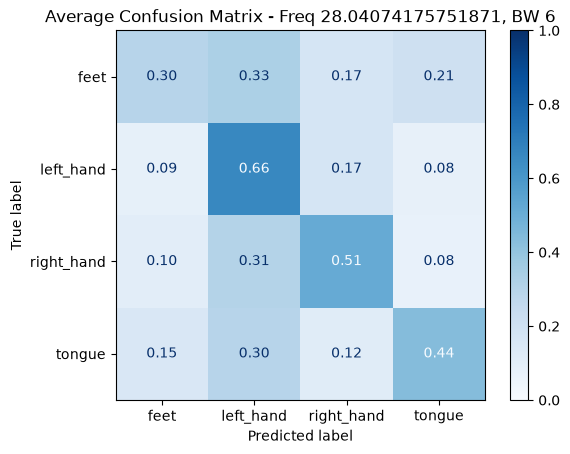


========== BANDWIDTH 6 ==========
acc: 0.4611 ± 0.0112
auc: 0.7237 ± 0.0158
fmeasure: 0.4214 ± 0.0173


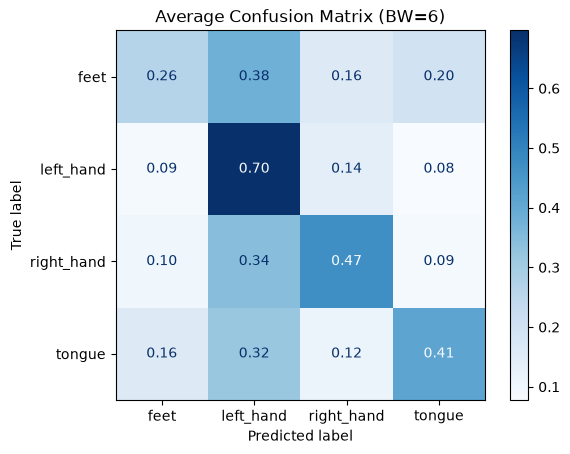



================ BANDWIDTH 8 ================

========== FREQ 25.670769359566975, BANDWIDTH 8 ==========
Early stopping at epoch 32
[[0.51388889 0.22222222 0.06944444 0.19444444]
 [0.02777778 0.88888889 0.07638889 0.00694444]
 [0.03472222 0.28472222 0.68055556 0.        ]
 [0.4375     0.20833333 0.01388889 0.34027778]]

Fold 1 Final Validation -
{'acc': 0.6059027777777778, 'auc': np.float64(0.8764829282407406), 'fmeasure': 0.5935188943009372}
Early stopping at epoch 25
[[0.15972222 0.52777778 0.23611111 0.07638889]
 [0.125      0.69444444 0.17361111 0.00694444]
 [0.06944444 0.60416667 0.30555556 0.02083333]
 [0.07638889 0.67361111 0.18055556 0.06944444]]

Fold 2 Final Validation -
{'acc': 0.3072916666666667, 'auc': np.float64(0.600951646090535), 'fmeasure': 0.26520347132744443}
Early stopping at epoch 47
[[0.38888889 0.08333333 0.13888889 0.38888889]
 [0.04166667 0.70138889 0.01388889 0.24305556]
 [0.04861111 0.08333333 0.59722222 0.27083333]
 [0.03472222 0.         0.00694444 0.958

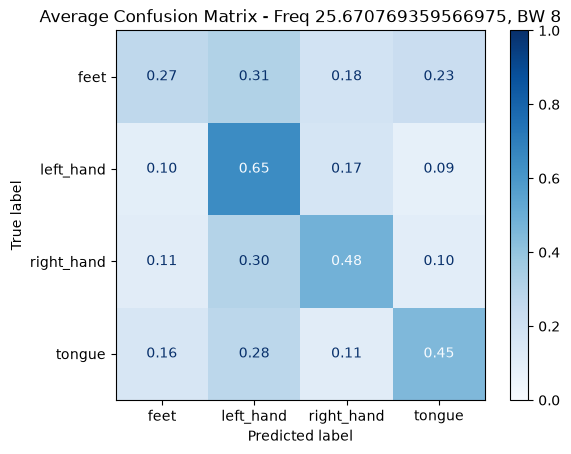


========== FREQ 16.288596313057464, BANDWIDTH 8 ==========
Early stopping at epoch 28
[[0.47916667 0.27777778 0.0625     0.18055556]
 [0.00694444 0.86805556 0.125      0.        ]
 [0.01388889 0.21527778 0.77083333 0.        ]
 [0.46527778 0.20833333 0.         0.32638889]]

Fold 1 Final Validation -
{'acc': 0.6111111111111112, 'auc': np.float64(0.8730508937757202), 'fmeasure': 0.5959304876412734}
Early stopping at epoch 16
[[0.11111111 0.88194444 0.         0.00694444]
 [0.15277778 0.84027778 0.         0.00694444]
 [0.11111111 0.88888889 0.         0.        ]
 [0.11111111 0.88888889 0.         0.        ]]

Fold 2 Final Validation -
{'acc': 0.2378472222222222, 'auc': np.float64(0.48587199395576136), 'fmeasure': 0.13074737510095766}
Early stopping at epoch 33
[[0.11805556 0.25       0.40277778 0.22916667]
 [0.00694444 0.88194444 0.02083333 0.09027778]
 [0.00694444 0.04861111 0.90277778 0.04166667]
 [0.01388889 0.03472222 0.02777778 0.92361111]]

Fold 3 Final Validation -
{'acc': 0.7

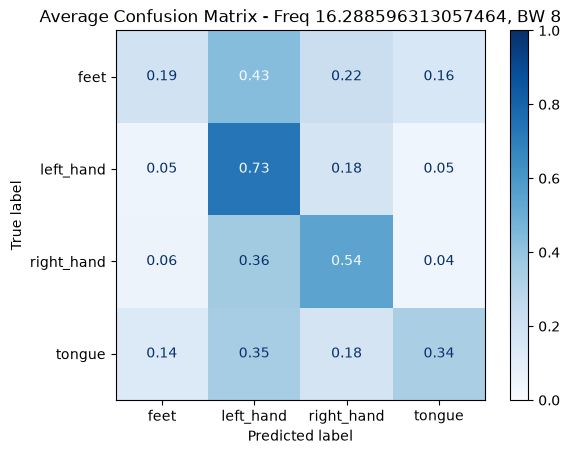


========== FREQ 28.04074175751871, BANDWIDTH 8 ==========
Early stopping at epoch 33
[[0.67361111 0.15277778 0.05555556 0.11805556]
 [0.02777778 0.75694444 0.20833333 0.00694444]
 [0.04166667 0.0625     0.89583333 0.        ]
 [0.52777778 0.16666667 0.         0.30555556]]

Fold 1 Final Validation -
{'acc': 0.6579861111111112, 'auc': np.float64(0.8734648276748972), 'fmeasure': 0.6394577096586449}
Early stopping at epoch 29
[[0.19444444 0.5        0.16666667 0.13888889]
 [0.15972222 0.61805556 0.20833333 0.01388889]
 [0.20138889 0.51388889 0.24305556 0.04166667]
 [0.13888889 0.65972222 0.14583333 0.05555556]]

Fold 2 Final Validation -
{'acc': 0.2777777777777778, 'auc': np.float64(0.5922670717592593), 'fmeasure': 0.2423787657379101}
Early stopping at epoch 42
[[0.52083333 0.11805556 0.04166667 0.31944444]
 [0.04166667 0.79166667 0.         0.16666667]
 [0.08333333 0.125      0.55555556 0.23611111]
 [0.03472222 0.01388889 0.         0.95138889]]

Fold 3 Final Validation -
{'acc': 0.7048

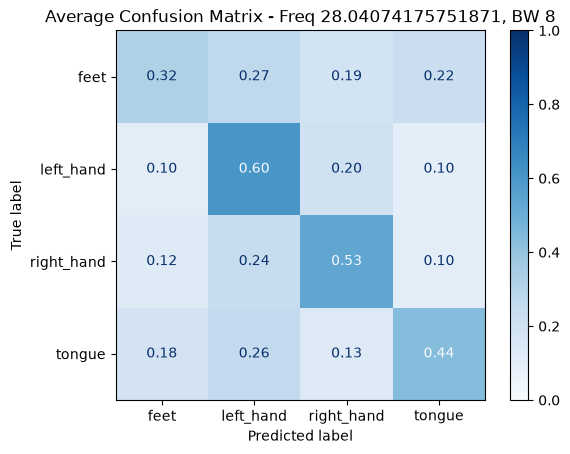


========== BANDWIDTH 8 ==========
acc: 0.4624 ± 0.0089
auc: 0.7276 ± 0.0135
fmeasure: 0.4211 ± 0.0200


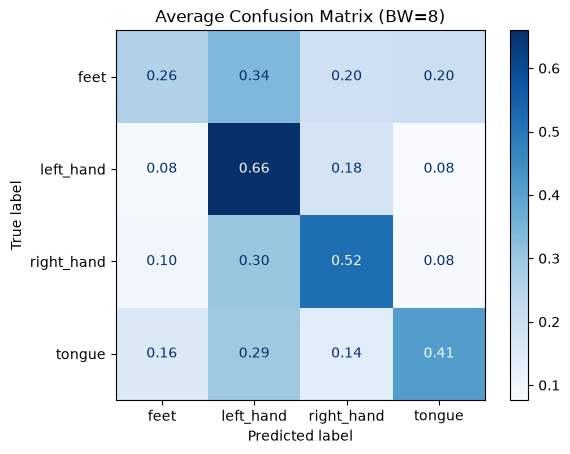

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
num_epochs = 60
results = {}
conf_mats = {}

for bw in [4, 6, 8]:
    bw_results = {}
    bw_conf_mats = {}

    print(f"\n\n================ BANDWIDTH {bw} ================")


    for freq in freqs:
        print(f"\n========== FREQ {freq}, BANDWIDTH {bw} ==========")

        fold_results = []
        fold_conf_mats = []

        for fold, (train_idx, valid_idx) in enumerate(logo.split(X_cv, y_cv, groups=subjects), start=1):

            X_tr = X_cv[train_idx].copy()
            X_va = X_cv[valid_idx].copy()
            
            y_tr = y_cv[train_idx]
            y_va = y_cv[valid_idx]

            X_va = _frequency_mask(freq, bw, X_va).copy()

            train_ds = TensorDataset(
                torch.tensor(X_tr, dtype=torch.float32),
                torch.tensor(y_tr, dtype=torch.long)
            )

            valid_ds = TensorDataset(
                torch.tensor(X_va, dtype=torch.float32),
                torch.tensor(y_va, dtype=torch.long)
            )

            train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
            valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

            net = EEGNetTorch(
                nb_classes=4,
                Chans=22,
                Samples=1001,
                kernLength=64,
                F1=32,
                D=4,
                F2=16,
                dropoutRate=0.4854763234903182,
            ).to(device)

            optimizer = torch.optim.Adam(
                net.parameters(),
                lr=0.0004102432506048275
            )

            criterion = torch.nn.CrossEntropyLoss()

            best_val_loss = float("inf")
            best_model_state = None
            epochs_without_improvement = 0

            for epoch in range(num_epochs):
                net.train()
                running_loss = 0.0
                n_seen = 0

                for inputs, labels in train_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    optimizer.zero_grad(set_to_none=True)
                    outputs = net(inputs)
                    loss = criterion(outputs, labels)

                    loss.backward()
                    optimizer.step()

                    running_loss += loss.item() * inputs.size(0)
                    n_seen += inputs.size(0)

                train_loss = running_loss / n_seen

                net.eval()
                val_loss = 0.0
                val_seen = 0

                with torch.no_grad():
                    for inputs, labels in valid_loader:
                        inputs = inputs.to(device)
                        labels = labels.to(device)

                        outputs = net(inputs)
                        loss = criterion(outputs, labels)

                        val_loss += loss.item() * inputs.size(0)
                        val_seen += inputs.size(0)

                val_loss = val_loss / val_seen

                if val_loss < best_val_loss - min_delta:
                    best_val_loss = val_loss
                    best_model_state = copy.deepcopy(net.state_dict())
                    epochs_without_improvement = 0
                else:
                    epochs_without_improvement += 1

                if epochs_without_improvement >= patience:
                    print(f"Early stopping at epoch {epoch + 1}")
                    break

            if best_model_state is not None:
                net.load_state_dict(best_model_state)

            metrics_raw = evaluate(net, X_va, y_va, params)

            if isinstance(metrics_raw, dict):
                metrics = metrics_raw
            else:
                metrics = dict(zip(params, metrics_raw))

            fold_results.append(metrics)

            net.eval()
            with torch.no_grad():
                X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
                outputs = net(X_tensor)
                y_pred = torch.argmax(outputs, dim=1).cpu().numpy()

            cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3], normalize="true")
            print(cm)
            fold_conf_mats.append(cm)

            print(f"\nFold {fold} Final Validation -")
            print(metrics)

        print(f"\n========== FREQ {freq}, BANDWIDTH {bw} Cross-Validation Results ==========")

        avg_metrics = {}

        for metric in params:
            values = [result[metric] for result in fold_results]
            avg_metrics[metric] = {
                "mean": np.mean(values),
                "std": np.std(values)
            }
            print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

        avg_cm = np.mean(fold_conf_mats, axis=0)
        bw_results[freq] = avg_metrics
        bw_conf_mats[freq] = avg_cm

        print("\nAverage Confusion Matrix:")
        print(avg_cm)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=avg_cm,
            display_labels=le.classes_
        )

        disp.plot(
            cmap="Blues",
            im_kw={"vmin": 0, "vmax": 1},
            values_format=".2f"
        )

        plt.title(f"Average Confusion Matrix - Freq {freq}, BW {bw}")
        plt.show()

        bw_results[freq] = avg_metrics
        bw_conf_mats[freq] = avg_cm
    
    bw_avg_metrics = {}

    for metric in params:
        means = [bw_results[f][metric]["mean"] for f in freqs]
        bw_avg_metrics[metric] = {
            "mean": np.mean(means),
            "std": np.std(means)
        }

    bw_avg_cm = np.mean(list(bw_conf_mats.values()), axis=0)

    print(f"\n========== BANDWIDTH {bw} ==========")
    for metric in params:
        print(f"{metric}: {bw_avg_metrics[metric]['mean']:.4f} ± {bw_avg_metrics[metric]['std']:.4f}")

    disp = ConfusionMatrixDisplay(
        confusion_matrix=bw_avg_cm,
        display_labels=le.classes_
    )
    disp.plot(cmap="Blues", values_format=".2f")
    plt.title(f"Average Confusion Matrix (BW={bw})")
    plt.show()

    results[bw] = bw_avg_metrics
    conf_mats[bw] = bw_avg_cm
